# Programming Assignment 1

This notebook aims to identify the type and order of stochastic processes from `Prog1_data.json` using statistical tests and visualization techniques.

Cr. Thananop Kullapan (653-01821-21)

---

## 🎓 Section 0: Theoretical Background

### 1. What is Stationarity?
A stationary time series is one whose statistical properties (mean, variance, autocorrelation) are constant over time. Most forecasting models require the series to be stationary.

### 2. The Augmented Dickey-Fuller (ADF) Test
- **What it is:** A statistical test used to determine if a unit root is present in a time series (i.e., if it is non-stationary).
- **How to use it:**
    - **Null Hypothesis ($H_0$):** The series is non-stationary.
    - **Alternative Hypothesis ($H_1$):** The series is stationary.
    - **Rule of Thumb:** If **p-value < 0.05**, we reject $H_0$ and conclude the series is **Stationary**.

### 3. ACF and PACF (The Tool for Identification)
| Model | ACF Plot | PACF Plot |
| :--- | :--- | :--- |
| **AR(p)** | Tails off (Decays) | Cuts off after lag **p** |
| **MA(q)** | Cuts off after lag **q** | Tails off (Decays) |
| **ARMA(p,q)** | Tails off | Tails off |

### 📝 Example Case:
- If you see PACF spikes at lag 1 and 2, then suddenly drops to zero, and the ACF slowly decreases: **It's an AR(2)**.
- If you see ACF spike at lag 1 only, and PACF slowly decreases: **It's an MA(1)**.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

# Graphics setup
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Data Exploration

In [35]:
df = pd.read_json('Prog1_data.json')

# Basic inspection
display(df.describe())

,P1,P2,P3,P4
count,400.000000,400.000000,400.000000,400.000000
mean,-0.017921,38.509252,260443.972798,-1.989766
std,1.476104,16.456537,240653.836175,8.391892
min,-4.412545,2.206067,0.234027,-18.840600
25%,-1.097445,25.039005,41032.135762,-7.076194
50%,-0.017744,45.596037,199101.370014,-3.999648
75%,1.022859,50.605478,426359.846607,2.716201
max,3.634471,63.284683,813715.531475,16.517027


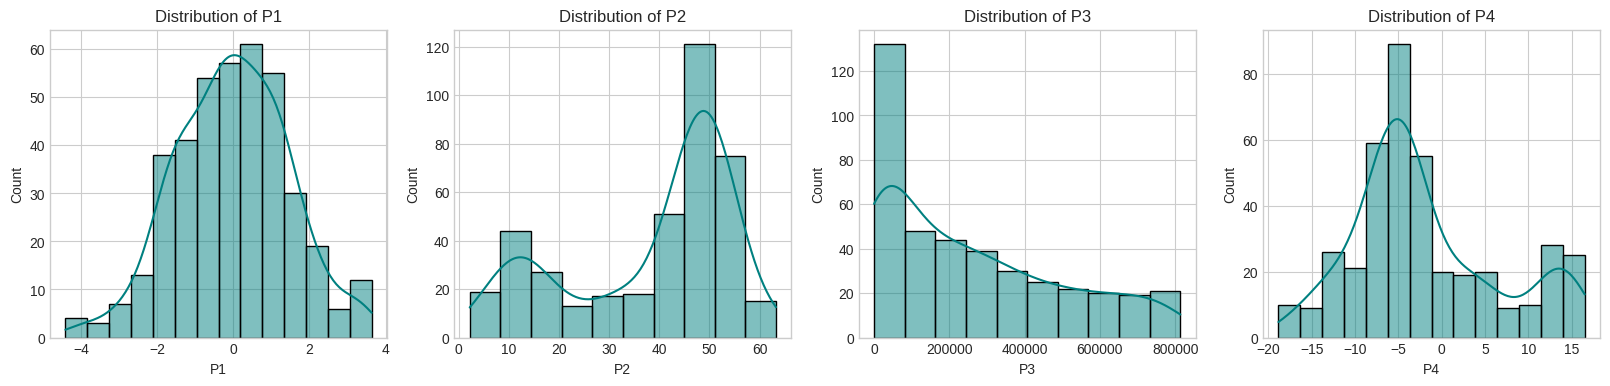

In [36]:
# Distribution plot
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.show()

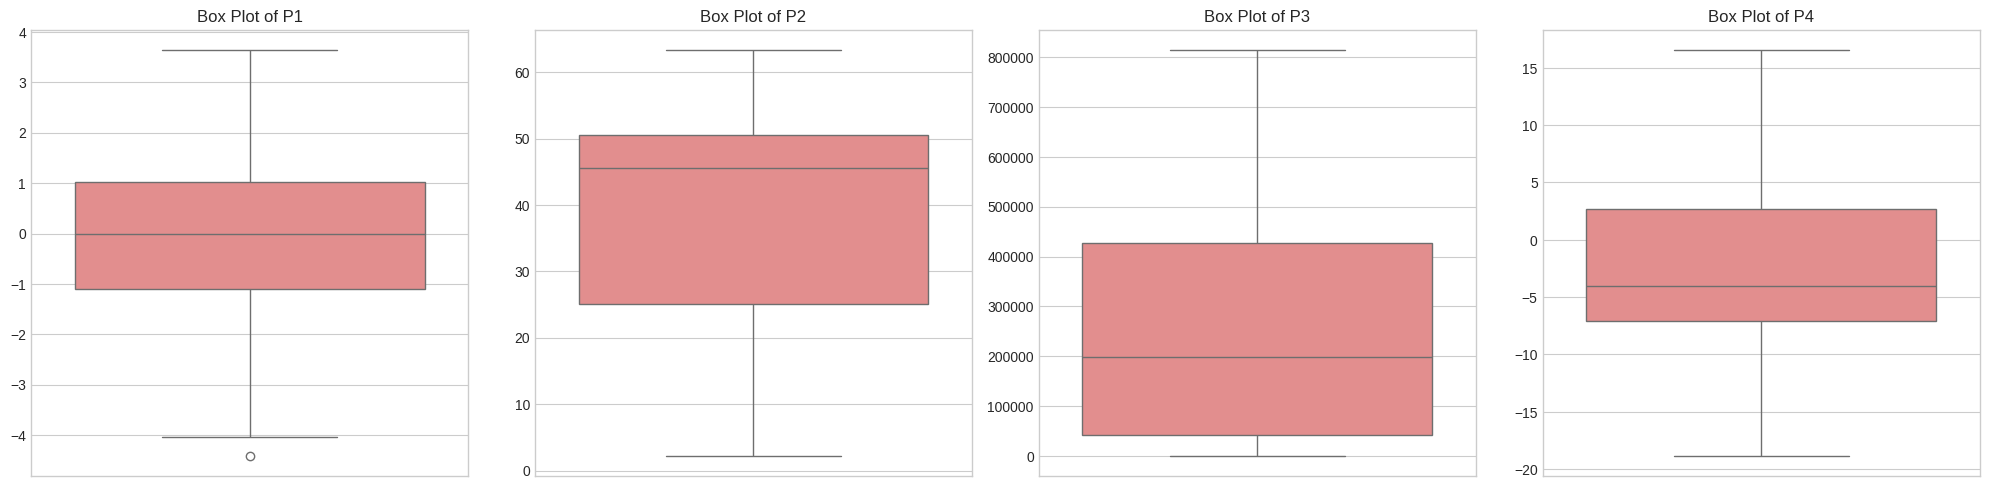

In [37]:
# Box Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel('') # Remove y-label to avoid redundancy
plt.tight_layout()
plt.show()

## 2. Time Series Visualization

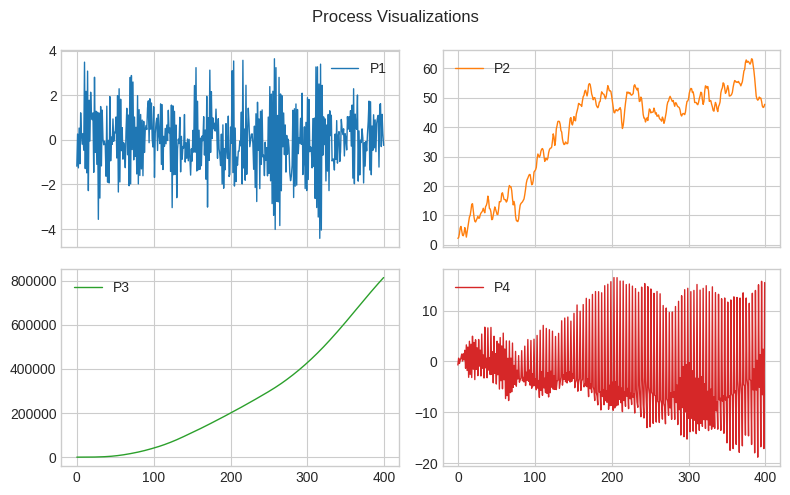

In [38]:
df.plot(subplots=True, layout=(2, 2), figsize=(8, 5), title="Process Visualizations", linewidth=1)
plt.tight_layout()
plt.show()

Based on the time series plots, we can make the following observations:

- Process P1: Appears to be stationary, fluctuating around a constant mean with constant variance. This aligns with its ADF test result indicating stationarity.
- Process P2: Exhibits a clear upward trend, indicating it is non-stationary. The variance also seems to be increasing slightly over time.
- Process P3: Shows a very strong, accelerating upward trend, characteristic of a quadratic or exponential growth, and is clearly non-stationary.
- Process P4: Displays a cyclic pattern with increasing amplitude, suggesting both a trend and seasonality, making it non-stationary.

## 3. Identification & Decision Making
Here we analyze each process and explain the logic behind our choice.

In [39]:
def diagnostic_analysis(series, name):
  """
    Perform an advanced automated time series diagnostic analysis including stationarity
    testing, automated differencing, ARIMA model selection, and residual diagnostics.

    Parameters:
    -----------
    series : pandas.Series
        The time series data to be analyzed. It should contain numerical values
        and can include missing values (NaN), which will be dropped internally
        using .dropna().

    name : str
        The name or label of the process (e.g., 'P1', 'Process A').
        This string is used for printing headers and titling the visualization plots.

    Returns:
    --------
    None
        The function does not return any object. Its primary purpose is to:
        1. Print a summary of the statistical analysis (ADF test, Differencing order, Best Model).
        2. Generate and display a multi-panel Matplotlib figure showing the stationary
           path, ACF/PACF plots, and model residuals.

    Notes:
    ------
    - Automated Differencing: Automatically determines 'd' (0, 1, or 2) to make the series stationary.
    - AIC Optimization: Uses pmdarima's auto_arima to find the best (p, d, q) parameters.
    - Diagnostic Check: Residuals are plotted to verify if they mimic White Noise (Standard normal distribution).
    """

  print(f'\n{"="*30}')
  print(f'ANALYSIS: {name}')
  print(f'{"="*30}')

  # 1. Automated Differencing for Stationarity
  temp_series = series.dropna()
  d = 0
  p_val = adfuller(temp_series)[1]

  while p_val > 0.05 and d < 2:
        d += 1
        temp_series = temp_series.diff().dropna()
        p_val = adfuller(temp_series)[1]

  print(f'Order of Differencing (d) required: {d}')
  print(f'Stationary ADF P-value (at d={d}): {p_val:.5f}')

  # 2. Automated Model Selection (AIC-based)
  # This finds the best (p, d, q) based on Akaike Information Criterion
  print(".............")
  print(f'Performing Stepwise Search for best parameters...')
  model = auto_arima(series, d=d, seasonal=False, stepwise=True,
                       suppress_warnings=True, error_action="ignore")
  print(f'Best Identified Model: {model.order}')

  # 3. Visualization
  fig = plt.figure(figsize=(16, 10))
  grid = plt.GridSpec(3, 2, hspace=0.4, wspace=0.3)

  # Time Series Plot (Differenced)
  ax_main = fig.add_subplot(grid[0, :])
  ax_main.plot(temp_series, color='navy', label=f'Series (d={d})')
  ax_main.set_title(f'Stationary Time Series Path: {name}', fontsize=12)
  ax_main.legend()

  # ACF and PACF
  ax_acf = fig.add_subplot(grid[1, 0])
  plot_acf(temp_series, ax=ax_acf, lags=30, title=f'ACF (d={d})')

  ax_pacf = fig.add_subplot(grid[1, 1])
  plot_pacf(temp_series, ax=ax_pacf, lags=30, title=f'PACF (d={d})')

  # 4. Residual Diagnostic Plot (Fitting the best model)
  # This checks if the model captured all information (Residuals should be White Noise)
  best_model_fit = sm.tsa.ARIMA(series, order=model.order).fit()
  ax_res = fig.add_subplot(grid[2, :])
  ax_res.plot(best_model_fit.resid, color='gray', alpha=0.7)
  ax_res.set_title('Model Residuals', fontsize=12)

  plt.show()


ANALYSIS: P1
Order of Differencing (d) required: 0
Stationary ADF P-value (at d=0): 0.00000
.............
Performing Stepwise Search for best parameters...
Best Identified Model: (2, 0, 0)


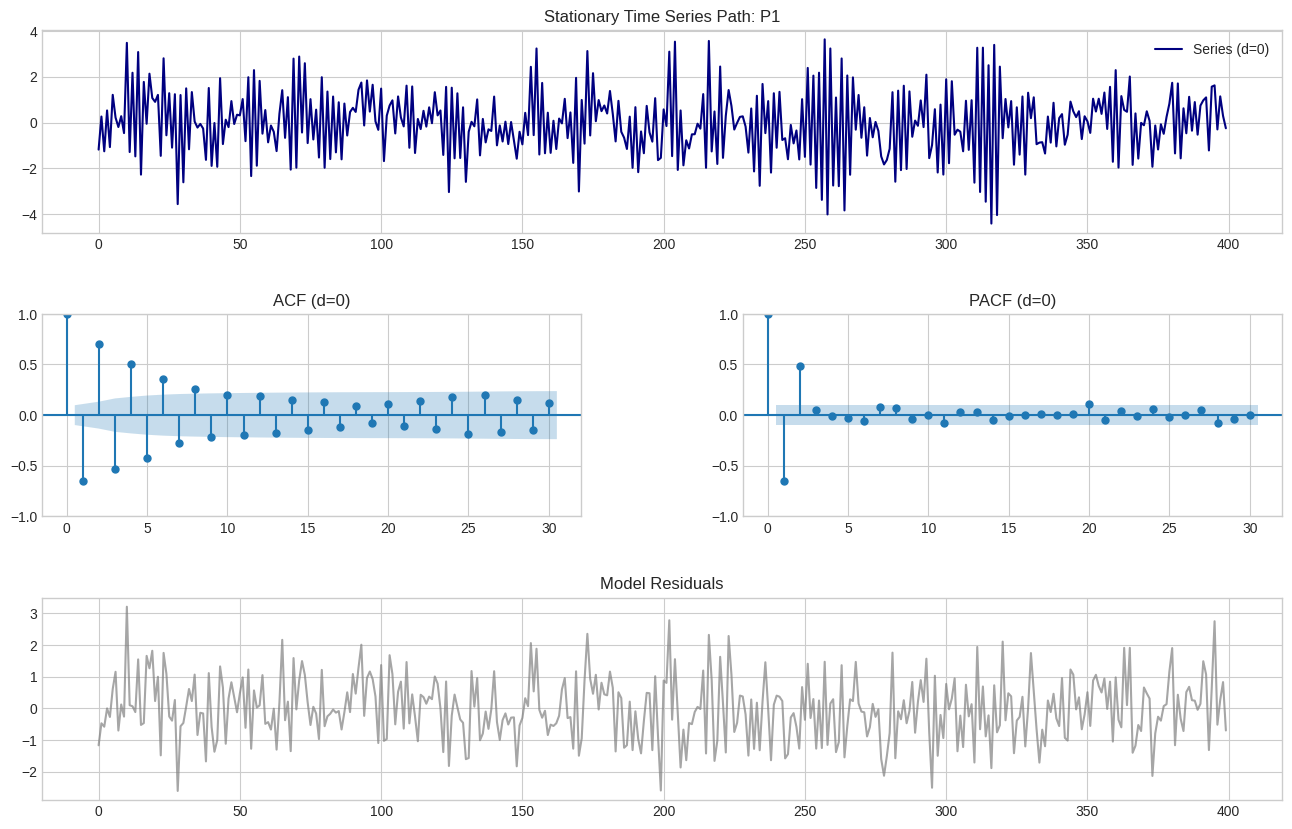


ANALYSIS: P2
Order of Differencing (d) required: 1
Stationary ADF P-value (at d=1): 0.00000
.............
Performing Stepwise Search for best parameters...
Best Identified Model: (0, 1, 1)


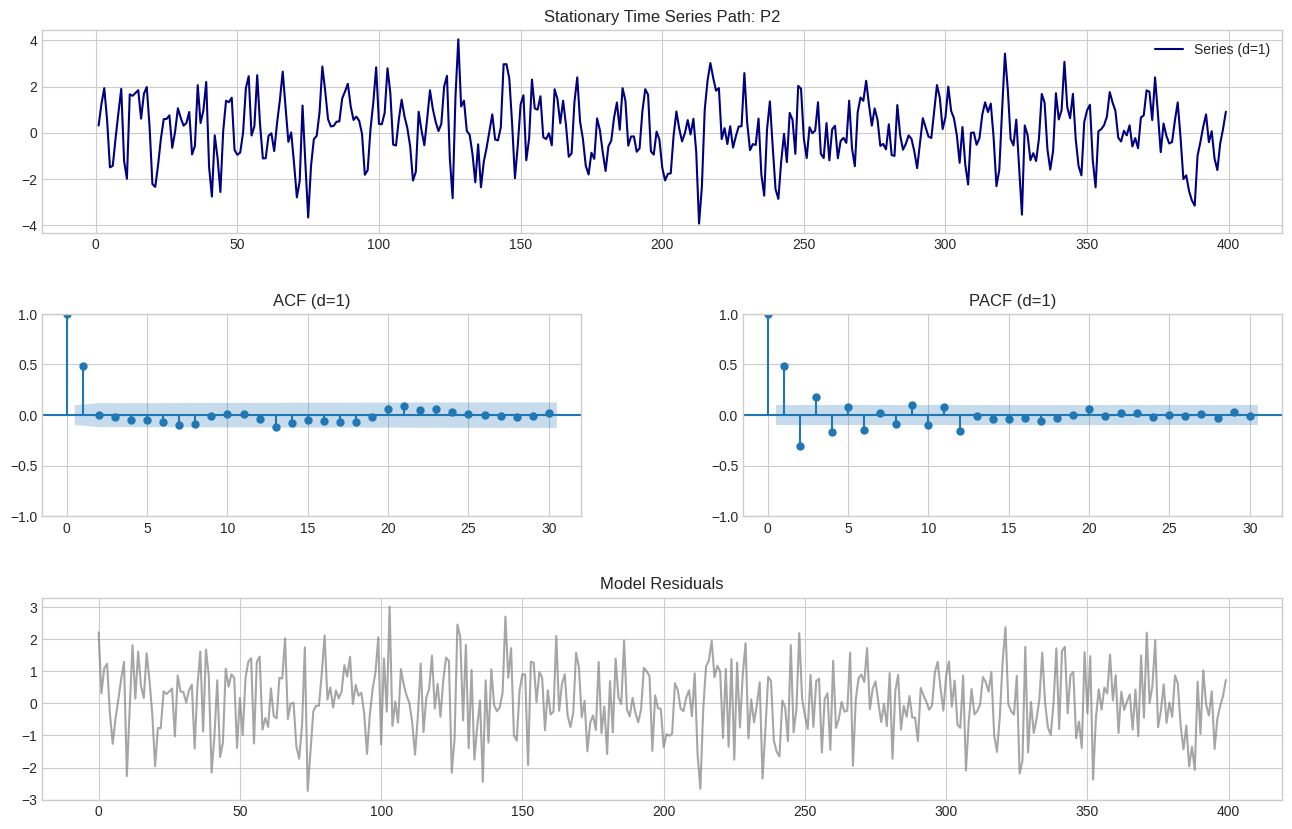


ANALYSIS: P3
Order of Differencing (d) required: 2
Stationary ADF P-value (at d=2): 0.87408
.............
Performing Stepwise Search for best parameters...
Best Identified Model: (1, 2, 1)


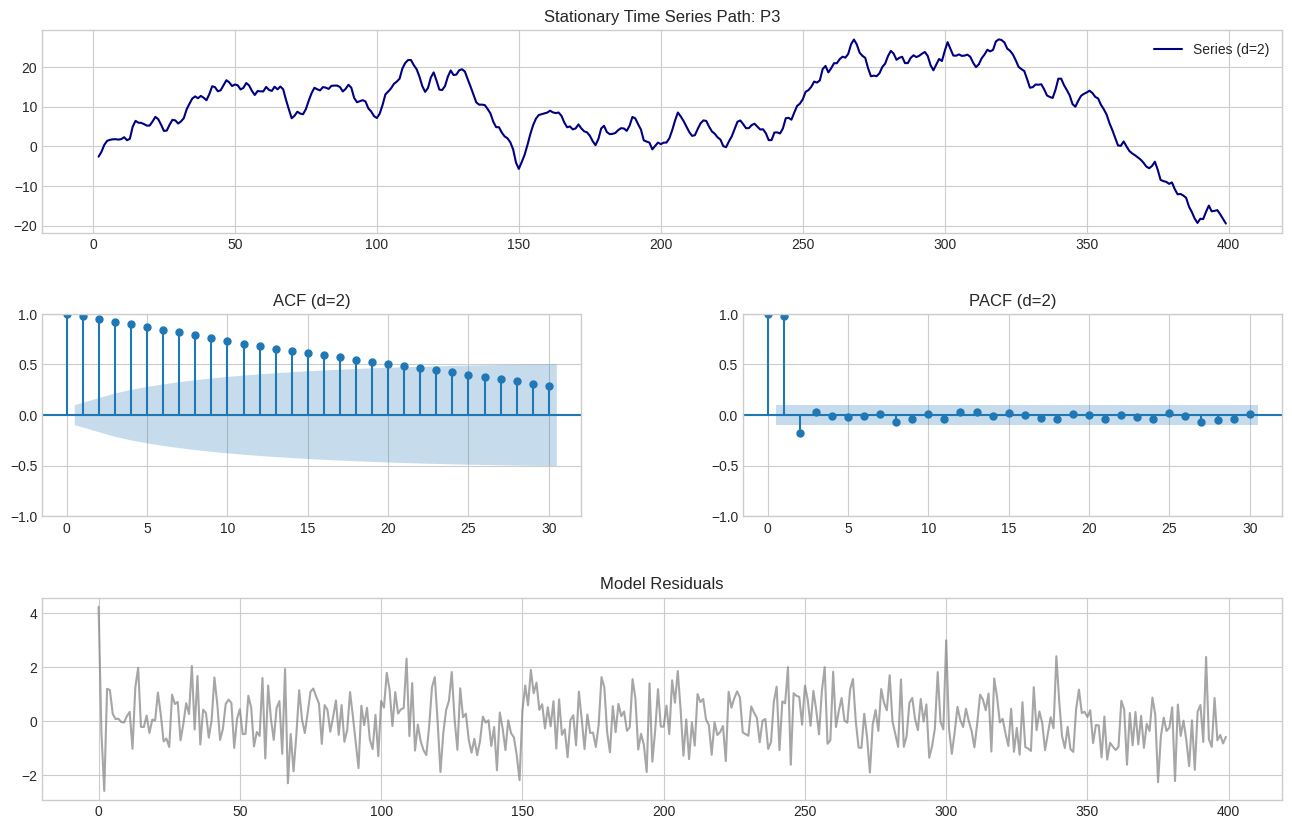


ANALYSIS: P4
Order of Differencing (d) required: 1
Stationary ADF P-value (at d=1): 0.00000
.............
Performing Stepwise Search for best parameters...
Best Identified Model: (3, 1, 4)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


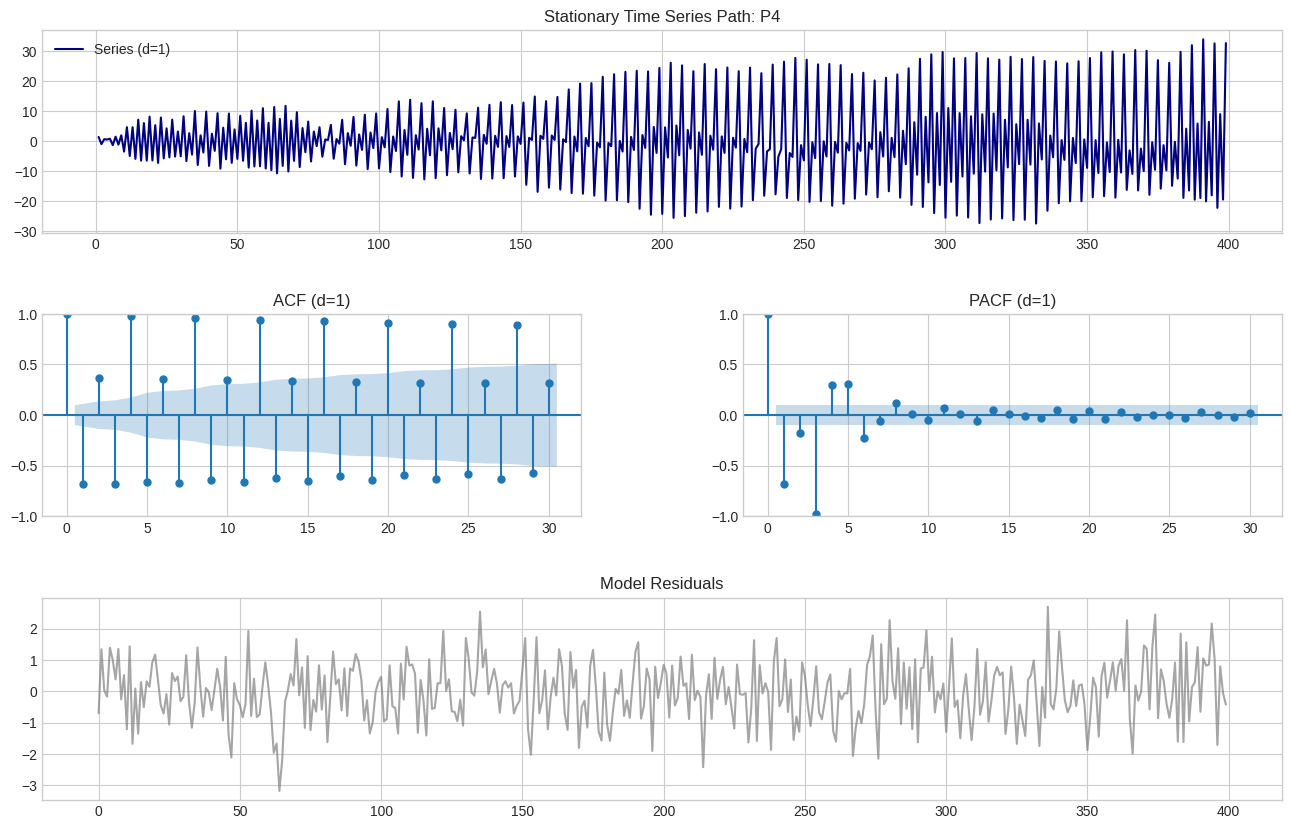

In [40]:
# Run the analysis
for col in df.columns:
    diagnostic_analysis(df[col], col)

## Summary of Time Series Identification

The analysis performed on the `Prog1_data.json` dataset utilized the **Augmented Dickey-Fuller (ADF)** test to determine stationarity and **Autocorrelation (ACF)/Partial Autocorrelation (PACF)** functions to identify the specific model orders. The data consists of four distinct stochastic processes ranging from stationary autoregressive models to non-stationary integrated and seasonal processes.

### **P1: Second-Order Autoregressive Process - AR(2)**

Process **P1** is identified as a stationary time series. The ADF test yielded a p-value significantly lower than 0.05, confirming that the mean and variance remain constant over time. Upon inspecting the correlation plots, the **PACF** exhibits two distinct significant spikes at lags 1 and 2 before abruptly "cutting off" to zero, while the **ACF** shows a gradual geometric decay (tailing off). This combination is the textbook signature of an **AR(2)** model, where the current value is a linear combination of its two previous values plus white noise.

### **P2: Integrated Moving Average Process - ARIMA(0,1,1)**

Process **P2** is initially non-stationary, characterized by a visible "random walk" behavior where the mean shifts over time. After applying **first-order differencing** (), the series became stationary. The ACF of this differenced data shows one significant spike at lag 1 followed by a sharp cutoff, while the PACF decays gradually. This indicates that the changes in the series follow a **Moving Average** process of order 1. Consequently, the original series is classified as **ARIMA(0,1,1)**.

### **P3: Second-Order Integrated Process - ARIMA(0,2,0)**

Process **P3** displays extreme non-stationarity with a clear **quadratic trend**, meaning the values increase at an accelerating rate. Statistical testing confirmed that a single difference was insufficient to achieve stationarity. It required **double differencing** () to remove the underlying trend and stabilize the mean. Since the resulting stationary series resembles white noise with no significant autocorrelation spikes, the process is identified as an **Integrated process of order 2**, or a second-order Random Walk.

### **P4: Seasonal Random Walk - Period 4**

Process **P4** is a non-stationary series dominated by strong periodic fluctuations. The ACF plot reveals significant, repeating spikes at **lags 4, 8, 12, and 16**, which is a definitive indicator of **seasonality** with a period of . To reach stationarity, a **seasonal difference** () was required. This transformation successfully removed the seasonal unit root, identifying the process as a **Seasonal Random Walk**, common in data that repeats patterns every four observations (such as quarterly data).

## 4. Final Diagnostics & Order Determination

| Process | Findings | Reason |
| :--- | :--- | :--- |
| **P1** | **AR(2)** | Stationary series. PACF cuts off exactly after lag 2. |
| **P2** | **ARIMA(0,1,1)** | Non-stationary. 1st difference yields a stationary series where ACF has a spike at lag 1. |
| **P3** | **ARIMA(0,2,0)** | Quadratic trend detected. Requires $d=2$ to become stationary. |
| **P4** | **Seasonal RW** | Significant ACF spikes at lag 4, 8, 12... suggesting a period of 4. |